In [1]:
import json
import os
import pandas as pd
import sys
sys.path.insert(1, '../scripts')

sys.path

from functions import create_df_of_requests
df = create_df_of_requests('../data/requests')

df.head()

,route_id,date,time,request_id,request_type,task_id,lat,lon,fixed,position_fixed
0,300,2022-06-17,05:57:33,41931cd2-8975-4a64-9197-d16abe871bb7,CreateSequence,395,0.565826,0.221868,False,NaN
1,300,2022-06-17,05:57:33,41931cd2-8975-4a64-9197-d16abe871bb7,CreateSequence,394,0.565826,0.221868,False,NaN
2,300,2022-06-17,08:50:02,5737d4ef-23e9-4832-8bb5-24340a176e31,CreateSequence,385,0.565826,0.221868,False,NaN
3,300,2022-06-17,08:50:02,5737d4ef-23e9-4832-8bb5-24340a176e31,CreateSequence,384,0.565826,0.221868,False,NaN
4,300,2022-06-17,09:24:16,34f409b3-9f92-4720-9926-48ca1cbf6f90,CreateSequence,390,0.565826,0.221868,False,NaN


In [2]:
from group_locations_helper_functions import group_locations_df

In [3]:
# Groepeer locaties op basis van lat/lon coördinaten
newdf = group_locations_df(df)

newdf.head()

,route_id,date,time,request_id,request_type,task_id,lat,lon,fixed,position_fixed,loc_id
0,300,2022-06-17,05:57:33,41931cd2-8975-4a64-9197-d16abe871bb7,CreateSequence,395,0.565826,0.221868,False,NaN,0
1,300,2022-06-17,05:57:33,41931cd2-8975-4a64-9197-d16abe871bb7,CreateSequence,394,0.565826,0.221868,False,NaN,0
2,300,2022-06-17,08:50:02,5737d4ef-23e9-4832-8bb5-24340a176e31,CreateSequence,385,0.565826,0.221868,False,NaN,0
3,300,2022-06-17,08:50:02,5737d4ef-23e9-4832-8bb5-24340a176e31,CreateSequence,384,0.565826,0.221868,False,NaN,0
4,300,2022-06-17,09:24:16,34f409b3-9f92-4720-9926-48ca1cbf6f90,CreateSequence,390,0.565826,0.221868,False,NaN,0


In [4]:
from group_locations_helper_functions import add_max_distance_per_loc_id

In [5]:
newdf = add_max_distance_per_loc_id(newdf)

In [6]:
newdf.sort_values(by="max_group_distance_m", ascending=[False])

,route_id,date,time,request_id,request_type,task_id,lat,lon,fixed,position_fixed,loc_id,max_group_distance_m
925344,625,2022-06-04,06:49:55,279aa4c6-f785-4f4d-bd6b-8ea3a2255868,EstimateTime,40192,0.630598,0.197905,True,42.0,38733,90.495819
977011,627,2022-06-17,08:27:03,8d9b808c-ba70-4e96-93fd-8f29903040f2,CreateSequence,41549,0.630850,0.197678,False,NaN,38733,90.495819
971906,627,2022-06-08,09:08:00,1c6e36b2-79f6-47ec-bb1e-a9d049177653,CreateSequence,38944,0.630817,0.197705,False,NaN,38733,90.495819
975695,627,2022-06-14,19:12:07,31517133-76ee-4626-b9cc-93627e2850d9,CreateSequence,100,0.631035,0.197522,False,NaN,38733,90.495819
975691,627,2022-06-14,19:12:07,31517133-76ee-4626-b9cc-93627e2850d9,CreateSequence,98,0.630755,0.197739,False,NaN,38733,90.495819
...,...,...,...,...,...,...,...,...,...,...,...,...
2576922,301,2022-05-30,19:11:46,a68b6188-e89e-4d5c-8c4a-b82ef7a71a84,AddToSequence,148,0.640092,0.311237,True,152.0,120,0.000000
2576923,301,2022-05-30,19:11:46,a68b6188-e89e-4d5c-8c4a-b82ef7a71a84,AddToSequence,147,0.636873,0.306125,True,153.0,119,0.000000
2576924,301,2022-05-30,19:11:46,a68b6188-e89e-4d5c-8c4a-b82ef7a71a84,AddToSequence,154,0.648065,0.301981,False,NaN,22,0.000000
2576925,301,2022-05-30,19:11:46,a68b6188-e89e-4d5c-8c4a-b82ef7a71a84,AddToSequence,155,0.648065,0.301981,False,NaN,22,0.000000


In [8]:
## retry calc distance, now with new function
## from group_locations_helper_functions import group_locations_df_v2

from group_locations_df_v2_helper_func import group_locations_df_v2

In [9]:
newdf3 = group_locations_df_v2(df)

newdf3.head()

,route_id,date,time,request_id,request_type,task_id,lat,lon,fixed,position_fixed,loc_id
0,300,2022-06-17,05:57:33,41931cd2-8975-4a64-9197-d16abe871bb7,CreateSequence,395,0.565826,0.221868,False,NaN,53639
1,300,2022-06-17,05:57:33,41931cd2-8975-4a64-9197-d16abe871bb7,CreateSequence,394,0.565826,0.221868,False,NaN,53639
2,300,2022-06-17,08:50:02,5737d4ef-23e9-4832-8bb5-24340a176e31,CreateSequence,385,0.565826,0.221868,False,NaN,53639
3,300,2022-06-17,08:50:02,5737d4ef-23e9-4832-8bb5-24340a176e31,CreateSequence,384,0.565826,0.221868,False,NaN,53639
4,300,2022-06-17,09:24:16,34f409b3-9f92-4720-9926-48ca1cbf6f90,CreateSequence,390,0.565826,0.221868,False,NaN,53639


In [10]:
newdf4 = add_max_distance_per_loc_id(newdf3)

In [11]:
newdf4.sort_values(by="max_group_distance_m", ascending=[False])

,route_id,date,time,request_id,request_type,task_id,lat,lon,fixed,position_fixed,loc_id,max_group_distance_m
596012,601,2022-06-15,08:30:35,3eb3ebb5-04f0-4f8f-8ba4-ca65acbda0e0,EstimateTime,58784,0.636125,0.146579,True,5.0,98300,12.778992
594547,601,2022-06-14,06:27:09,a85c349f-6055-4b8e-923e-6f62671ecad3,CreateSequence,58248,0.636075,0.146625,False,NaN,98300,12.778992
592345,601,2022-06-09,19:12:02,7f065954-037c-40b2-a8b6-05823cf52e6a,AddToSequence,20,0.636041,0.146657,True,37.0,98300,12.778992
596316,601,2022-06-15,19:11:37,2eaeafd8-af43-429f-8750-20dace3bc43c,AddToSequence,4,0.636041,0.146657,True,35.0,98300,12.778992
600357,601,2022-06-21,19:12:25,2bc4e5c3-3a44-47b3-8fbb-ef656c51c69b,CreateSequence,36,0.636041,0.146657,False,NaN,98300,12.778992
...,...,...,...,...,...,...,...,...,...,...,...,...
2576922,301,2022-05-30,19:11:46,a68b6188-e89e-4d5c-8c4a-b82ef7a71a84,AddToSequence,148,0.640092,0.311237,True,152.0,99092,0.000000
2576923,301,2022-05-30,19:11:46,a68b6188-e89e-4d5c-8c4a-b82ef7a71a84,AddToSequence,147,0.636873,0.306125,True,153.0,98444,0.000000
2576924,301,2022-05-30,19:11:46,a68b6188-e89e-4d5c-8c4a-b82ef7a71a84,AddToSequence,154,0.648065,0.301981,False,NaN,100837,0.000000
2576925,301,2022-05-30,19:11:46,a68b6188-e89e-4d5c-8c4a-b82ef7a71a84,AddToSequence,155,0.648065,0.301981,False,NaN,100837,0.000000


In [12]:
##quickfix correct, will need to split this up for better naming

df = newdf4 

## Taak 3a.1.a: Detecteren of AANTAL locaties is gewijzigd

**Vraag**: Per request bepalen of het AANTAL locaties (task id's) is gewijzigd?

**Antwoord**: JA/NEE (True/False) binnen 1 route op een bepaalde dag

In [13]:
def add_location_count_changed(df: pd.DataFrame) -> pd.DataFrame:
    """
    Bepaal of het aantal unieke locaties is gewijzigd over verschillende requests
    voor elke route op elke dag.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe met kolommen: route_id, date, request_id, loc_id
    
    Returns:
    --------
    pd.DataFrame
        Originele dataframe met nieuwe boolean kolom 'location_count_changed'
        - True: aantal locaties varieerde over requests
        - False: aantal locaties bleef constant
    """
    df = df.copy()
    
    # Stap 1: Tel unieke loc_id per route_id + date + request_id
    counts = (
        df.groupby(["route_id", "date", "request_id"])["loc_id"]
        .nunique()
        .reset_index(name="n_unique_loc")
    )
    
    # Stap 2: Controleer of aantallen veranderen over request_id voor elke route_id + date
    # Als er meer dan één unieke telwaarde is, is het aantal gewijzigd
    changed = (
        counts.groupby(["route_id", "date"])["n_unique_loc"]
        .nunique()
        .gt(1)  # Meer dan één unieke telling → aantal gewijzigd
        .reset_index(name="location_count_changed")
    )
    
    # Stap 3: Merge terug naar originele dataframe
    df = df.merge(changed, on=["route_id", "date"], how="left")
    
    return df

In [14]:
# Pas de functie toe
newdf2 = add_location_count_changed(newdf)

newdf2.head(150)

,route_id,date,time,request_id,request_type,task_id,lat,lon,fixed,position_fixed,loc_id,max_group_distance_m,location_count_changed
0,300,2022-06-17,05:57:33,41931cd2-8975-4a64-9197-d16abe871bb7,CreateSequence,395,0.565826,0.221868,False,NaN,0,0.0,True
1,300,2022-06-17,05:57:33,41931cd2-8975-4a64-9197-d16abe871bb7,CreateSequence,394,0.565826,0.221868,False,NaN,0,0.0,True
2,300,2022-06-17,08:50:02,5737d4ef-23e9-4832-8bb5-24340a176e31,CreateSequence,385,0.565826,0.221868,False,NaN,0,0.0,True
3,300,2022-06-17,08:50:02,5737d4ef-23e9-4832-8bb5-24340a176e31,CreateSequence,384,0.565826,0.221868,False,NaN,0,0.0,True
4,300,2022-06-17,09:24:16,34f409b3-9f92-4720-9926-48ca1cbf6f90,CreateSequence,390,0.565826,0.221868,False,NaN,0,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,301,2022-05-30,06:45:38,cb9638db-2817-4ccf-b226-7775c01793a8,EstimateTime,64955,0.642867,0.303686,True,134.0,107,0.0,True
146,301,2022-05-30,06:45:38,cb9638db-2817-4ccf-b226-7775c01793a8,EstimateTime,64977,0.642685,0.303240,True,135.0,108,0.0,True
147,301,2022-05-30,06:45:38,cb9638db-2817-4ccf-b226-7775c01793a8,EstimateTime,64986,0.642198,0.302969,True,136.0,109,0.0,True
148,301,2022-05-30,06:45:38,cb9638db-2817-4ccf-b226-7775c01793a8,EstimateTime,64919,0.642220,0.304321,True,137.0,110,0.0,True


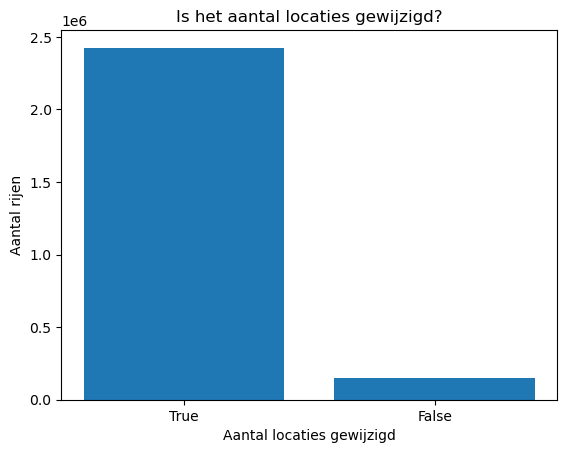

In [15]:
import matplotlib.pyplot as plt

# Tel True / False
counts = newdf2["location_count_changed"].value_counts()

plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Aantal locaties gewijzigd")
plt.ylabel("Aantal rijen")
plt.title("Is het aantal locaties gewijzigd?")
plt.show()

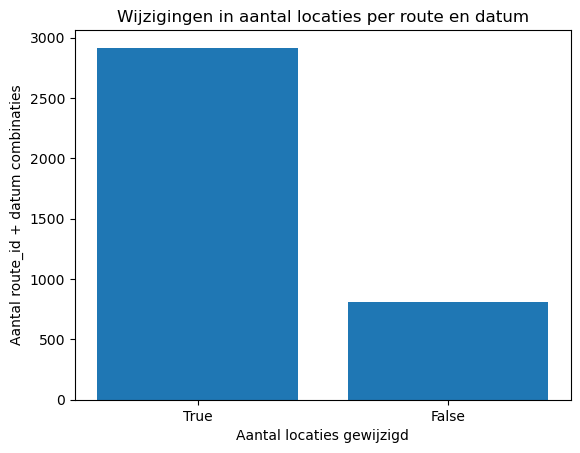

In [16]:
# Beter overzicht: één rij per route+datum combinatie
route_level = (
    newdf2[["route_id", "date", "location_count_changed"]]
    .drop_duplicates()
)

counts = route_level["location_count_changed"].value_counts()

plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Aantal locaties gewijzigd")
plt.ylabel("Aantal route_id + datum combinaties")
plt.title("Wijzigingen in aantal locaties per route en datum")
plt.show()

## Taak 3a.1.c: Berekenen HOEVEEL locaties zijn gewijzigd

**Vraag**: Hoeveel locaties toegevoegd of verwijderd werden?

**Antwoord**: Absolute aantallen + relatieve percentages

In [17]:
def add_location_change_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Bereken hoeveel locaties zijn toegevoegd, verwijderd en netto verandering
    tussen eerste en laatste request voor elke route per dag.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe met kolommen: route_id, date, request_id, loc_id
    
    Returns:
    --------
    pd.DataFrame
        Originele dataframe met nieuwe kolommen:
        - locations_added: aantal loc_ids in laatste request maar niet in eerste
        - locations_removed: aantal loc_ids in eerste request maar niet in laatste
        - locations_net_change: netto verandering (toegevoegd - verwijderd)
        - locations_change_pct: percentage verandering t.o.v. eerste request
    """
    df = df.copy()
    
    # Stap 1: Haal vroegste en laatste request_id per route_id + date
    req_order = (
        df.groupby(["route_id", "date"])["request_id"]
        .agg(["min", "max"])
        .reset_index()
        .rename(columns={"min": "first_request", "max": "last_request"})
    )
    
    # Stap 2: Verzamel set van loc_ids in eerste request
    first_locs = (
        df.merge(req_order, on=["route_id", "date"])
        .query("request_id == first_request")
        .groupby(["route_id", "date"])["loc_id"]
        .apply(set)
        .reset_index(name="first_locs")
    )
    
    # Stap 3: Verzamel set van loc_ids in laatste request
    last_locs = (
        df.merge(req_order, on=["route_id", "date"])
        .query("request_id == last_request")
        .groupby(["route_id", "date"])["loc_id"]
        .apply(set)
        .reset_index(name="last_locs")
    )
    
    # Stap 4: Bereken toevoegingen, verwijderingen en netto verandering
    diff = (
        first_locs.merge(last_locs, on=["route_id", "date"])
        .assign(
            # Locaties in laatste maar niet in eerste = toegevoegd
            locations_added=lambda x: x.apply(
                lambda row: len(row["last_locs"] - row["first_locs"]), axis=1
            ),
            # Locaties in eerste maar niet in laatste = verwijderd
            locations_removed=lambda x: x.apply(
                lambda row: len(row["first_locs"] - row["last_locs"]), axis=1
            ),
            # Netto verandering (kan negatief zijn als meer verwijderd dan toegevoegd)
            locations_net_change=lambda x: x.apply(
                lambda row: len(row["last_locs"]) - len(row["first_locs"]), axis=1
            ),
            # Percentage verandering relatief t.o.v. eerste request aantal
            locations_change_pct=lambda x: x.apply(
                lambda row: (len(row["last_locs"]) - len(row["first_locs"])) / 
                           len(row["first_locs"]) * 100 if len(row["first_locs"]) > 0 else 0,
                axis=1
            )
        )[["route_id", "date", "locations_added", "locations_removed", 
           "locations_net_change", "locations_change_pct"]]
    )
    
    # Stap 5: Merge terug naar originele dataframe
    df = df.merge(diff, on=["route_id", "date"], how="left")
    
    return df

In [18]:
# Pas de functie toe
newdf3 = add_location_change_metrics(newdf2)

newdf3.head(150)

,route_id,date,time,request_id,request_type,task_id,lat,lon,fixed,position_fixed,loc_id,max_group_distance_m,location_count_changed,locations_added,locations_removed,locations_net_change,locations_change_pct
0,300,2022-06-17,05:57:33,41931cd2-8975-4a64-9197-d16abe871bb7,CreateSequence,395,0.565826,0.221868,False,NaN,0,0.0,True,1,2,-1,-50.0
1,300,2022-06-17,05:57:33,41931cd2-8975-4a64-9197-d16abe871bb7,CreateSequence,394,0.565826,0.221868,False,NaN,0,0.0,True,1,2,-1,-50.0
2,300,2022-06-17,08:50:02,5737d4ef-23e9-4832-8bb5-24340a176e31,CreateSequence,385,0.565826,0.221868,False,NaN,0,0.0,True,1,2,-1,-50.0
3,300,2022-06-17,08:50:02,5737d4ef-23e9-4832-8bb5-24340a176e31,CreateSequence,384,0.565826,0.221868,False,NaN,0,0.0,True,1,2,-1,-50.0
4,300,2022-06-17,09:24:16,34f409b3-9f92-4720-9926-48ca1cbf6f90,CreateSequence,390,0.565826,0.221868,False,NaN,0,0.0,True,1,2,-1,-50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,301,2022-05-30,06:45:38,cb9638db-2817-4ccf-b226-7775c01793a8,EstimateTime,64955,0.642867,0.303686,True,134.0,107,0.0,True,0,0,0,0.0
146,301,2022-05-30,06:45:38,cb9638db-2817-4ccf-b226-7775c01793a8,EstimateTime,64977,0.642685,0.303240,True,135.0,108,0.0,True,0,0,0,0.0
147,301,2022-05-30,06:45:38,cb9638db-2817-4ccf-b226-7775c01793a8,EstimateTime,64986,0.642198,0.302969,True,136.0,109,0.0,True,0,0,0,0.0
148,301,2022-05-30,06:45:38,cb9638db-2817-4ccf-b226-7775c01793a8,EstimateTime,64919,0.642220,0.304321,True,137.0,110,0.0,True,0,0,0,0.0


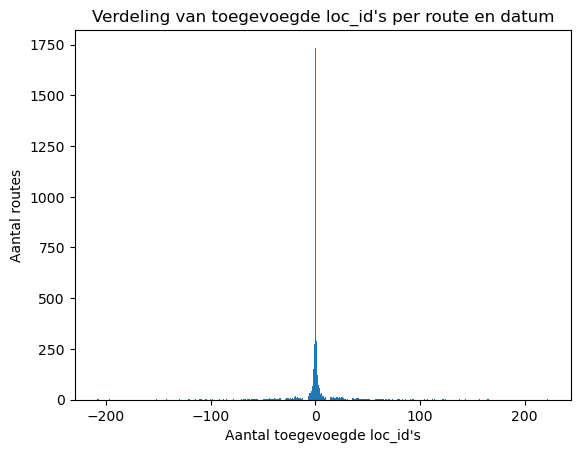

In [19]:
# Gebruik één rij per route_id + datum
route_level = (
    newdf3[["route_id", "date", "locations_added", "locations_removed", 
            "locations_net_change", "locations_change_pct"]]
    .drop_duplicates()
)

# Verdeling van netto veranderingen
counts = route_level["locations_net_change"].value_counts().sort_index()

plt.figure()
plt.bar(counts.index, counts.values)
plt.xlabel("Aantal toegevoegde loc_id's")
plt.ylabel("Aantal routes")
plt.title("Verdeling van toegevoegde loc_id's per route en datum")
plt.show()

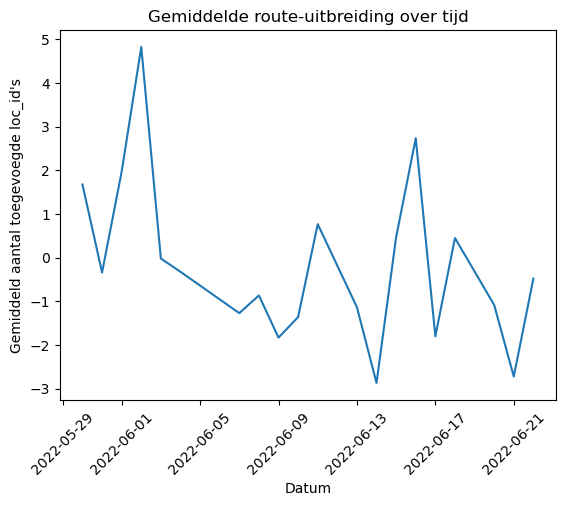

In [20]:
# Tijdreeks: gemiddelde veranderingen over tijd
time_plot = (
    route_level
    .groupby("date")["locations_net_change"]
    .mean()
)

plt.figure()
plt.plot(time_plot.index, time_plot.values)
plt.xlabel("Datum")
plt.ylabel("Gemiddeld aantal toegevoegde loc_id's")
plt.title("Gemiddelde route-uitbreiding over tijd")
plt.xticks(rotation=45)
plt.show()

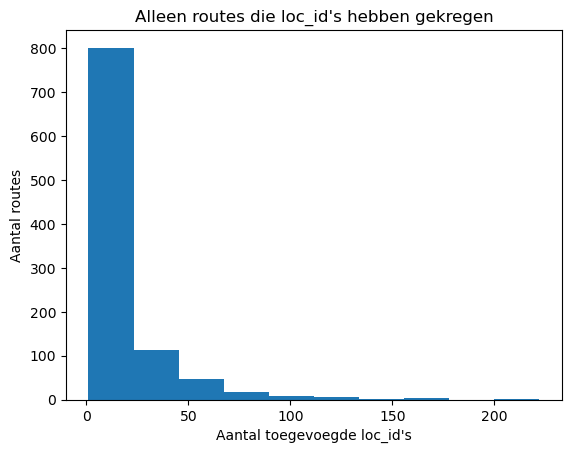

In [21]:
# Alleen routes die loc_id's hebben gekregen
changed_only = route_level.query("locations_net_change > 0")

plt.figure()
plt.hist(changed_only["locations_net_change"])
plt.xlabel("Aantal toegevoegde loc_id's")
plt.ylabel("Aantal routes")
plt.title("Alleen routes die loc_id's hebben gekregen")
plt.show()

## Taak 3a.2.a: Detecteren of VOLGORDE van locaties is gewijzigd

**Vraag**: Per request bepalen of de VOLGORDE van de locaties is gewijzigd?

**Antwoord**: True/False binnen 1 route

**Belangrijke opmerking**: We vergelijken alleen **GEMEENSCHAPPELIJKE locaties** tussen opeenvolgende requests om valse positieven te voorkomen wanneer locaties worden toegevoegd/verwijderd.

In [22]:
import pandas as pd

def add_order_changed(df: pd.DataFrame) -> pd.DataFrame:
    """
    Bepaal of de volgorde van locaties is gewijzigd tussen opeenvolgende requests
    voor elke route op elke dag.
    
    Beschouwt alleen GEMEENSCHAPPELIJKE locaties (aanwezig in beide requests) om
    valse positieven door toevoegingen/verwijderingen te vermijden.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe met kolommen: route_id, date, request_id, loc_id, time, position_fixed
    
    Returns:
    --------
    pd.DataFrame
        Originele dataframe met nieuwe boolean kolom 'order_changed'
        - True: de relatieve volgorde van gemeenschappelijke locaties is gewijzigd
        - False: volgorde bleef hetzelfde (of eerste request, of geen gemeenschappelijke locaties)
    """
    df = df.copy()
    
    # Stap 1: Bouw sorteerbare datetime voor juiste ordening
    df["datetime"] = pd.to_datetime(
        df["date"].astype(str) + " " + df["time"].astype(str),
        errors='coerce'
    )
    
    # Stap 2: Bouw geordende loc_id sequenties per request
    # Sorteer op datetime en position_fixed om de werkelijke bezoekorder te krijgen
    request_sequences = (
        df.sort_values(["route_id", "date", "request_id", "datetime", "position_fixed"])
        .groupby(["route_id", "date", "request_id"])
        .agg(
            loc_sequence=("loc_id", tuple),  # Geordende tuple van locaties
            request_time=("datetime", "min")  # Tijdstempel van request
        )
        .reset_index()
    )
    
    # Stap 3: Sorteer requests chronologisch binnen elke route+datum
    request_sequences = request_sequences.sort_values(
        ["route_id", "date", "request_time"]
    )
    
    # Stap 4: Vergelijk elk request met het vorige
    def compare_order(group):
        """
        Vergelijk opeenvolgende requests binnen een route+datum groep.
        Vergelijkt alleen gemeenschappelijke locaties om valse positieven te vermijden.
        """
        group = group.sort_values("request_time").reset_index(drop=True)
        order_changed = []
        
        for i in range(len(group)):
            if i == 0:
                # Eerste request: geen vorig request om mee te vergelijken
                order_changed.append(False)
            else:
                prev_seq = group.loc[i-1, "loc_sequence"]
                curr_seq = group.loc[i, "loc_sequence"]
                
                # Vind gemeenschappelijke locaties
                prev_set = set(prev_seq)
                curr_set = set(curr_seq)
                common = prev_set & curr_set
                
                if len(common) == 0:
                    # Geen gemeenschappelijke locaties: kan volgorde niet vergelijken
                    order_changed.append(False)
                else:
                    # Extraheer subsequentie van gemeenschappelijke locaties in hun originele volgorde
                    prev_common = tuple(loc for loc in prev_seq if loc in common)
                    curr_common = tuple(loc for loc in curr_seq if loc in common)
                    
                    # Vergelijk: is de relatieve volgorde gewijzigd?
                    order_changed.append(prev_common != curr_common)
        
        group["order_changed"] = order_changed
        return group
    
    request_sequences = (
        request_sequences
        .groupby(["route_id", "date"], group_keys=False)
        .apply(compare_order)
        .reset_index(drop=True)
    )
    
    # Stap 5: Merge terug naar originele dataframe
    df = df.merge(
        request_sequences[["route_id", "date", "request_id", "order_changed"]],
        on=["route_id", "date", "request_id"],
        how="left"
    )
    
    # Stap 6: Opruimen van tijdelijke kolom
    df = df.drop(columns=["datetime"])
    
    return df

In [24]:
# Pas de functie toe
newdf4 = add_order_changed(newdf3)

newdf4.head()



C:\Users\mmylle\AppData\Local\Temp\ipykernel_16700\4155309204.py:87: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compare_order)


,route_id,date,time,request_id,request_type,task_id,lat,lon,fixed,position_fixed,loc_id,max_group_distance_m,location_count_changed,locations_added,locations_removed,locations_net_change,locations_change_pct,order_changed
0,300,2022-06-17,05:57:33,41931cd2-8975-4a64-9197-d16abe871bb7,CreateSequence,395,0.565826,0.221868,False,NaN,0,0.0,True,1,2,-1,-50.0,False
1,300,2022-06-17,05:57:33,41931cd2-8975-4a64-9197-d16abe871bb7,CreateSequence,394,0.565826,0.221868,False,NaN,0,0.0,True,1,2,-1,-50.0,False
2,300,2022-06-17,08:50:02,5737d4ef-23e9-4832-8bb5-24340a176e31,CreateSequence,385,0.565826,0.221868,False,NaN,0,0.0,True,1,2,-1,-50.0,False
3,300,2022-06-17,08:50:02,5737d4ef-23e9-4832-8bb5-24340a176e31,CreateSequence,384,0.565826,0.221868,False,NaN,0,0.0,True,1,2,-1,-50.0,False
4,300,2022-06-17,09:24:16,34f409b3-9f92-4720-9926-48ca1cbf6f90,CreateSequence,390,0.565826,0.221868,False,NaN,0,0.0,True,1,2,-1,-50.0,True


In [25]:
newdf4.tail(150)

,route_id,date,time,request_id,request_type,task_id,lat,lon,fixed,position_fixed,loc_id,max_group_distance_m,location_count_changed,locations_added,locations_removed,locations_net_change,locations_change_pct,order_changed
2576777,301,2022-05-30,19:11:46,a68b6188-e89e-4d5c-8c4a-b82ef7a71a84,AddToSequence,13,0.648751,0.298210,True,7.0,15,0.0,True,0,0,0,0.0,True
2576778,301,2022-05-30,19:11:46,a68b6188-e89e-4d5c-8c4a-b82ef7a71a84,AddToSequence,14,0.649293,0.299105,True,8.0,16,0.0,True,0,0,0,0.0,True
2576779,301,2022-05-30,19:11:46,a68b6188-e89e-4d5c-8c4a-b82ef7a71a84,AddToSequence,18,0.649301,0.300469,True,9.0,18,0.0,True,0,0,0,0.0,True
2576780,301,2022-05-30,19:11:46,a68b6188-e89e-4d5c-8c4a-b82ef7a71a84,AddToSequence,20,0.649220,0.300745,True,10.0,19,0.0,True,0,0,0,0.0,True
2576781,301,2022-05-30,19:11:46,a68b6188-e89e-4d5c-8c4a-b82ef7a71a84,AddToSequence,19,0.649220,0.300745,True,11.0,19,0.0,True,0,0,0,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2576922,301,2022-05-30,19:11:46,a68b6188-e89e-4d5c-8c4a-b82ef7a71a84,AddToSequence,148,0.640092,0.311237,True,152.0,120,0.0,True,0,0,0,0.0,True
2576923,301,2022-05-30,19:11:46,a68b6188-e89e-4d5c-8c4a-b82ef7a71a84,AddToSequence,147,0.636873,0.306125,True,153.0,119,0.0,True,0,0,0,0.0,True
2576924,301,2022-05-30,19:11:46,a68b6188-e89e-4d5c-8c4a-b82ef7a71a84,AddToSequence,154,0.648065,0.301981,False,NaN,22,0.0,True,0,0,0,0.0,True
2576925,301,2022-05-30,19:11:46,a68b6188-e89e-4d5c-8c4a-b82ef7a71a84,AddToSequence,155,0.648065,0.301981,False,NaN,22,0.0,True,0,0,0,0.0,True


## Taak 3a.2.b: Berekenen HOEVEEL locaties van volgorde zijn gewijzigd

**Vraag**: Hoeveel task id's van volgorde gewijzigd zijn?

**Antwoord**: Werkelijk aantal locaties dat van positie is veranderd

**Methode**: We gebruiken **Kendall tau afstand** (aantal paargewijze inversies) om volgorde-wijzigingen te kwantificeren

In [26]:
def add_order_change_count(df: pd.DataFrame) -> pd.DataFrame:
    """
    Tel hoeveel locaties van positie zijn veranderd tussen opeenvolgende requests.
    
    Gebruikt Kendall tau afstand (aantal paargewijze verwisselingen nodig) om
    de omvang van volgorde-wijzigingen te kwantificeren.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe met kolommen: route_id, date, request_id, loc_id, time, position_fixed
    
    Returns:
    --------
    pd.DataFrame
        Originele dataframe met nieuwe kolommen:
        - order_changes_count: aantal paargewijze positie-verwisselingen (inversies)
        - order_changes_pct: percentage van mogelijke verwisselingen die plaatsvonden
    """
    df = df.copy()
    
    # Stap 1: Bouw sorteerbare datetime
    df["datetime"] = pd.to_datetime(
        df["date"].astype(str) + " " + df["time"].astype(str),
        errors='coerce'
    )
    
    # Stap 2: Bouw geordende loc_id sequenties per request
    request_sequences = (
        df.sort_values(["route_id", "date", "request_id", "datetime", "position_fixed"])
        .groupby(["route_id", "date", "request_id"])
        .agg(
            loc_sequence=("loc_id", tuple),
            request_time=("datetime", "min")
        )
        .reset_index()
    )
    
    # Stap 3: Sorteer requests chronologisch
    request_sequences = request_sequences.sort_values(
        ["route_id", "date", "request_time"]
    )
    
    # Stap 4: Bereken Kendall tau afstand (aantal paargewijze verwisselingen)
    def count_order_changes(group):
        """
        Tel paargewijze inversies tussen opeenvolgende requests.
        
        Een inversie vindt plaats wanneer twee locaties in tegengestelde volgorde
        verschijnen in het huidige request vergeleken met het vorige request.
        """
        group = group.sort_values("request_time").reset_index(drop=True)
        change_counts = []
        change_pcts = []
        
        for i in range(len(group)):
            if i == 0:
                # Eerste request: geen vergelijking
                change_counts.append(0)
                change_pcts.append(0.0)
            else:
                prev_seq = list(group.loc[i-1, "loc_sequence"])
                curr_seq = list(group.loc[i, "loc_sequence"])
                
                # Vind gemeenschappelijke locaties
                common = set(prev_seq) & set(curr_seq)
                
                if len(common) < 2:
                    # Minstens 2 gemeenschappelijke items nodig om volgorde te hebben
                    change_counts.append(0)
                    change_pcts.append(0.0)
                else:
                    # Extraheer gemeenschappelijke subsequenties
                    prev_common = [loc for loc in prev_seq if loc in common]
                    curr_common = [loc for loc in curr_seq if loc in common]
                    
                    # Maak positie mapping voor vorige sequentie
                    prev_positions = {loc: idx for idx, loc in enumerate(prev_common)}
                    
                    # Tel inversies: hoeveel paren zijn uit volgorde?
                    inversions = 0
                    n = len(curr_common)
                    for j in range(n):
                        for k in range(j + 1, n):
                            # Als curr_common[j] na curr_common[k] kwam in prev_common
                            if prev_positions[curr_common[j]] > prev_positions[curr_common[k]]:
                                inversions += 1
                    
                    # Maximum mogelijke inversies voor n items: n*(n-1)/2
                    max_inversions = n * (n - 1) / 2
                    pct = (inversions / max_inversions * 100) if max_inversions > 0 else 0
                    
                    change_counts.append(inversions)
                    change_pcts.append(pct)
        
        group["order_changes_count"] = change_counts
        group["order_changes_pct"] = change_pcts
        return group
    
    request_sequences = (
        request_sequences
        .groupby(["route_id", "date"], group_keys=False)
        .apply(count_order_changes)
        .reset_index(drop=True)
    )
    
    # Stap 5: Merge terug
    df = df.merge(
        request_sequences[["route_id", "date", "request_id", 
                          "order_changes_count", "order_changes_pct"]],
        on=["route_id", "date", "request_id"],
        how="left"
    )
    
    # Stap 6: Opruimen
    df = df.drop(columns=["datetime"])
    
    return df

In [27]:
# Pas de functie toe
newdf5 = add_order_change_count(newdf4)
newdf5.head(150)

C:\Users\mmylle\AppData\Local\Temp\ipykernel_16700\2659335397.py:103: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_order_changes)


,route_id,date,time,request_id,request_type,task_id,lat,lon,fixed,position_fixed,loc_id,max_group_distance_m,location_count_changed,locations_added,locations_removed,locations_net_change,locations_change_pct,order_changed,order_changes_count,order_changes_pct
0,300,2022-06-17,05:57:33,41931cd2-8975-4a64-9197-d16abe871bb7,CreateSequence,395,0.565826,0.221868,False,NaN,0,0.0,True,1,2,-1,-50.0,False,0,0.0
1,300,2022-06-17,05:57:33,41931cd2-8975-4a64-9197-d16abe871bb7,CreateSequence,394,0.565826,0.221868,False,NaN,0,0.0,True,1,2,-1,-50.0,False,0,0.0
2,300,2022-06-17,08:50:02,5737d4ef-23e9-4832-8bb5-24340a176e31,CreateSequence,385,0.565826,0.221868,False,NaN,0,0.0,True,1,2,-1,-50.0,False,0,0.0
3,300,2022-06-17,08:50:02,5737d4ef-23e9-4832-8bb5-24340a176e31,CreateSequence,384,0.565826,0.221868,False,NaN,0,0.0,True,1,2,-1,-50.0,False,0,0.0
4,300,2022-06-17,09:24:16,34f409b3-9f92-4720-9926-48ca1cbf6f90,CreateSequence,390,0.565826,0.221868,False,NaN,0,0.0,True,1,2,-1,-50.0,True,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,301,2022-05-30,06:45:38,cb9638db-2817-4ccf-b226-7775c01793a8,EstimateTime,64955,0.642867,0.303686,True,134.0,107,0.0,True,0,0,0,0.0,False,0,0.0
146,301,2022-05-30,06:45:38,cb9638db-2817-4ccf-b226-7775c01793a8,EstimateTime,64977,0.642685,0.303240,True,135.0,108,0.0,True,0,0,0,0.0,False,0,0.0
147,301,2022-05-30,06:45:38,cb9638db-2817-4ccf-b226-7775c01793a8,EstimateTime,64986,0.642198,0.302969,True,136.0,109,0.0,True,0,0,0,0.0,False,0,0.0
148,301,2022-05-30,06:45:38,cb9638db-2817-4ccf-b226-7775c01793a8,EstimateTime,64919,0.642220,0.304321,True,137.0,110,0.0,True,0,0,0,0.0,False,0,0.0


## Visualisaties: Volgorde-wijzigingen

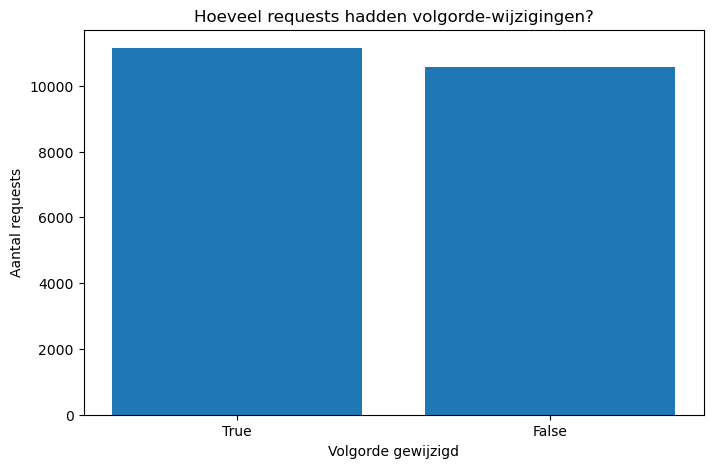

In [28]:
# Één rij per request
request_level = (
    newdf5[["route_id", "date", "request_id", "order_changed", 
            "order_changes_count", "order_changes_pct"]]
    .drop_duplicates()
)

# Hoeveel requests hadden volgorde-wijzigingen?
counts = request_level["order_changed"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Volgorde gewijzigd")
plt.ylabel("Aantal requests")
plt.title("Hoeveel requests hadden volgorde-wijzigingen?")
plt.show()

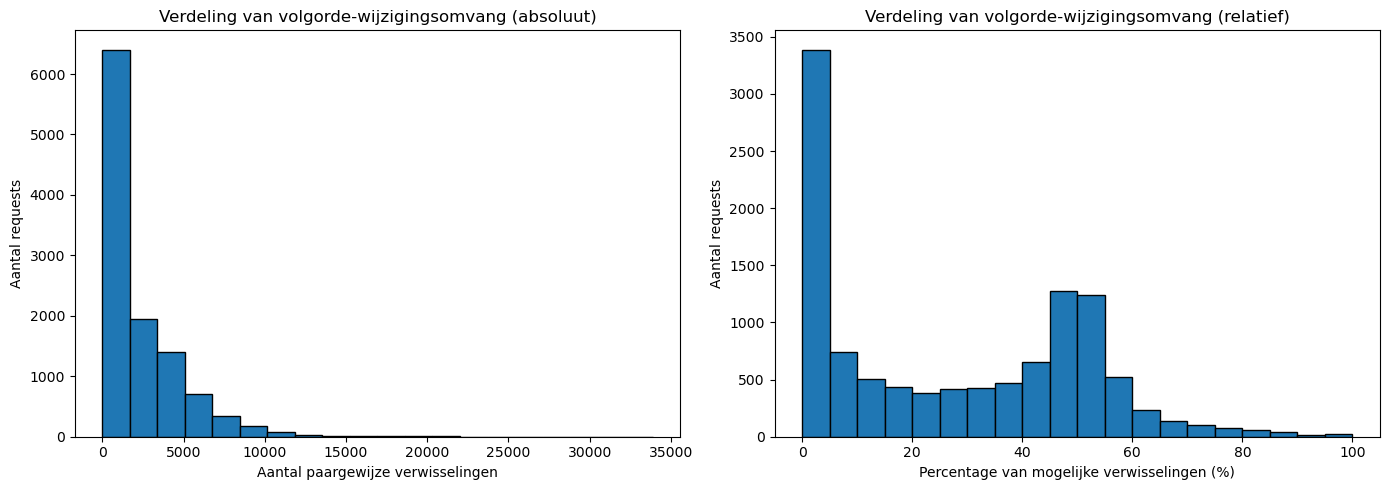

In [29]:
# Verdeling van volgorde-wijzigingsomvang (voor requests met wijzigingen)
changed_requests = request_level.query("order_changed == True")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Aantal inversies
axes[0].hist(changed_requests["order_changes_count"], bins=20, edgecolor='black')
axes[0].set_xlabel("Aantal paargewijze verwisselingen")
axes[0].set_ylabel("Aantal requests")
axes[0].set_title("Verdeling van volgorde-wijzigingsomvang (absoluut)")

# Percentage inversies
axes[1].hist(changed_requests["order_changes_pct"], bins=20, edgecolor='black')
axes[1].set_xlabel("Percentage van mogelijke verwisselingen (%)")
axes[1].set_ylabel("Aantal requests")
axes[1].set_title("Verdeling van volgorde-wijzigingsomvang (relatief)")

plt.tight_layout()
plt.show()

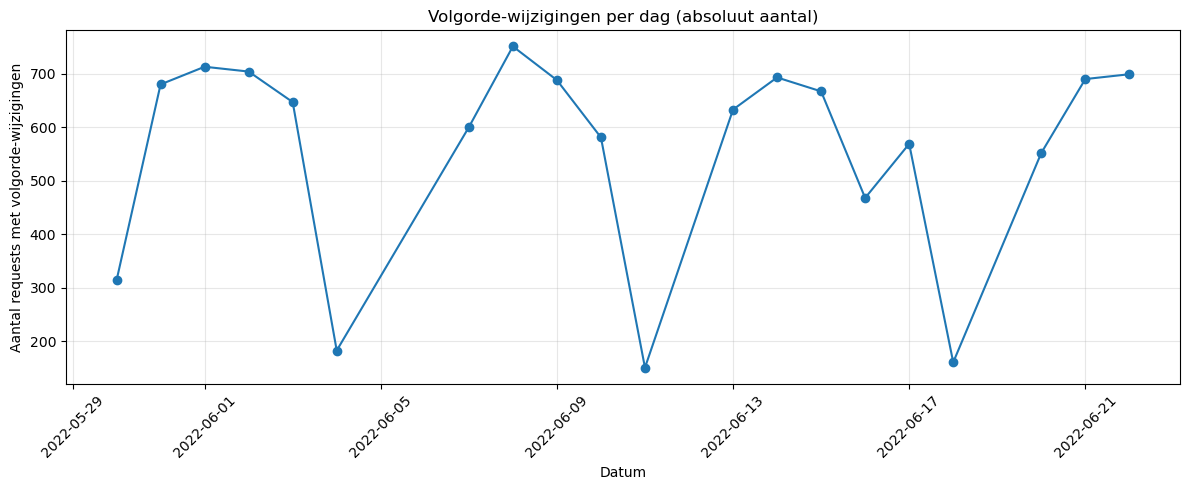

In [30]:
# Tijdreeks: volgorde-wijzigingen per dag
daily_changes = (
    request_level
    .groupby("date")["order_changed"]
    .sum()
)

plt.figure(figsize=(12, 5))
plt.plot(daily_changes.index, daily_changes.values, marker='o')
plt.xlabel("Datum")
plt.ylabel("Aantal requests met volgorde-wijzigingen")
plt.title("Volgorde-wijzigingen per dag (absoluut aantal)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

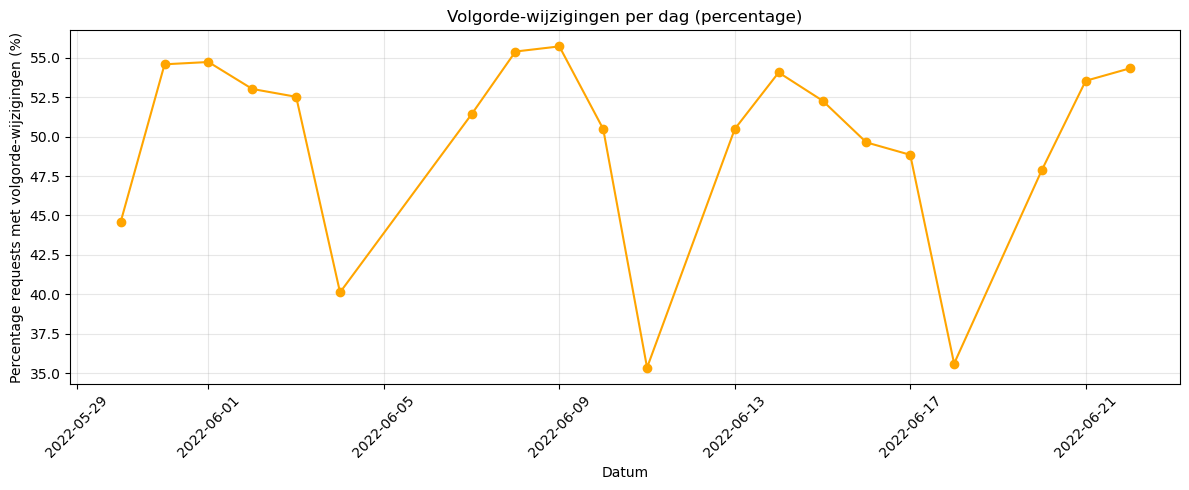

In [31]:
# Tijdreeks: fractie van requests met volgorde-wijzigingen
daily_fraction = (
    request_level
    .groupby("date")["order_changed"]
    .mean() * 100
)

plt.figure(figsize=(12, 5))
plt.plot(daily_fraction.index, daily_fraction.values, marker='o', color='orange')
plt.xlabel("Datum")
plt.ylabel("Percentage requests met volgorde-wijzigingen (%)")
plt.title("Volgorde-wijzigingen per dag (percentage)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

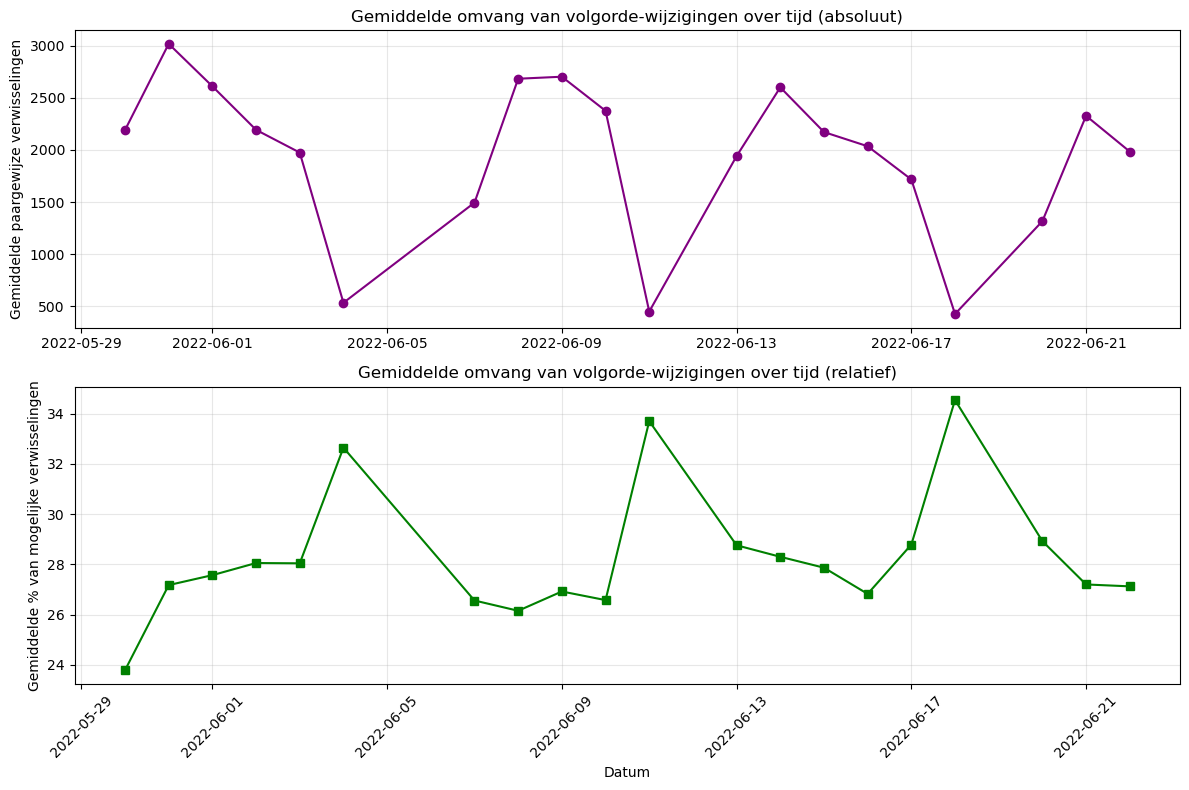

In [32]:
# Gemiddelde omvang van volgorde-wijzigingen over tijd (voor requests met wijzigingen)
daily_magnitude = (
    request_level.query("order_changed == True")
    .groupby("date")[["order_changes_count", "order_changes_pct"]]
    .mean()
)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(daily_magnitude.index, daily_magnitude["order_changes_count"], 
             marker='o', color='purple')
axes[0].set_ylabel("Gemiddelde paargewijze verwisselingen")
axes[0].set_title("Gemiddelde omvang van volgorde-wijzigingen over tijd (absoluut)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(daily_magnitude.index, daily_magnitude["order_changes_pct"], 
             marker='s', color='green')
axes[1].set_xlabel("Datum")
axes[1].set_ylabel("Gemiddelde % van mogelijke verwisselingen")
axes[1].set_title("Gemiddelde omvang van volgorde-wijzigingen over tijd (relatief)")
axes[1].grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()